In [4]:
import pandas as pd
import numpy as np
import scipy.io as sio
import torch
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features
import torch.utils


In [5]:
phase1_data = sio.loadmat('../data/mine_impact_data_2019.mat')
samples  = pd.DataFrame(phase1_data["x"].T)
labels  = pd.DataFrame(phase1_data["y"].T, columns=["y"])

df = pd.concat([samples, labels], axis=1, join="inner")

df = df.dropna()


In [27]:

shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]

data = Extract_Features(df_X, df_Y, feature="dict_learning", n_components=256, random_state=42, alpha=0.1, max_iter=100,batch_size=512)



In [28]:
print(data.get_samples().shape)

(3309, 256)


0.7152103559870551
              precision    recall  f1-score   support

           0       0.80      0.79      0.79       215
           1       0.53      0.55      0.54        94

    accuracy                           0.72       309
   macro avg       0.67      0.67      0.67       309
weighted avg       0.72      0.72      0.72       309



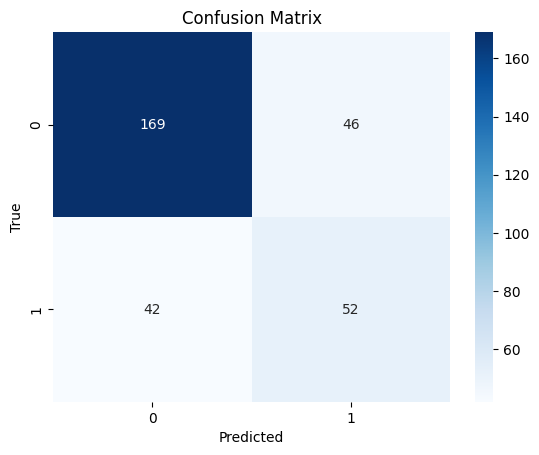

In [29]:
from sklearn.svm import SVC, LinearSVC

svc = SVC(kernel="rbf", C=100)
svc.fit(data.get_samples()[:3000], data.get_labels()[:3000])
print(svc.score(data.get_samples()[3000:], data.get_labels()[3000:]))

from sklearn.metrics import confusion_matrix, classification_report

y_pred = svc.predict(data.get_samples()[3000:])

print(classification_report(data.get_labels()[3000:], y_pred))


cm = confusion_matrix(data.get_labels()[3000:], y_pred)
#matplot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(data.get_labels()), yticklabels=np.unique(data.get_labels()))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [30]:
train_idx = list(range(0, 3000))
test_idx = list(range(3000,3308))

train_data = torch.utils.data.Subset(data, train_idx)
test_data = torch.utils.data.Subset(data, test_idx)

batch_size = 1

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)


In [31]:
input_dim = data[0][0].shape
print("Input dimension: ", input_dim)

Input dimension:  torch.Size([256])


In [32]:
def init_train_var(model):
  criterion = torch.nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)

  return criterion, optimizer

In [36]:
from classification_models import classification

def train(train_loader, batch_size, epochs):
  device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

  model = classification.MLP(nb_hidden=64, input_dim=input_dim[0], output_dim=2)
  model.to(device)
  
  criterion, optimizer = init_train_var(model=model)
  history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }
  train_steps = len(train_loader.dataset) // batch_size
#   val_steps = len(val_loader.dataset) // batch_size

  nb_epochs = epochs
  # run for nb_epochs
  for e in range(nb_epochs):
      # set the model in training mode
      model.train()
      # initialize the total training and validation loss
      epoch_train_loss = 0
    #   epoch_val_loss = 0
      # initialize the number of correct predictions in the training
      # and validation step
      train_correct = 0
    #   val_correct = 0

      for x, y in train_loader:
          
          x, y = x.to(device), y.to(device)
          optimizer.zero_grad()

          pred = model(x)
          loss = criterion(pred, y)
          loss.backward()
          optimizer.step()

          # add the loss to the total training loss so far and
          # calculate the number of correct predictions
          epoch_train_loss += loss
          train_correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    #   # switch off autograd for validation
    #   with torch.no_grad():
    #       # set the model in evaluation mode
    #       model.eval()
    #       # loop over the validation set
    #       for (x, y) in val_loader:

    #           x, y = x.to(device), y.to(device)
    #           pred = model(x)
    #           loss = criterion(pred, y)
    #           epoch_val_loss += loss
    #           val_correct += (pred.argmax(1) == y).type(torch.float).sum().item()



      # calculate the average epoch training and validation loss
      mean_train_loss = epoch_train_loss / train_steps
    #   mean_val_loss = epoch_val_loss / val_steps
      # calculate the training and validation accuracy
      train_correct = train_correct / len(train_loader.dataset)
      # val_correct = val_correct / len(val_loader.dataset)
      # update our training history
      history["train_loss"].append(mean_train_loss.cpu().detach().numpy())
      history["train_acc"].append(train_correct)
    #   history["val_loss"].append(mean_val_loss.cpu().detach().numpy())
      # history["val_acc"].append(val_correct)
      # print the model training and validation information
      print("[INFO] EPOCH: {}/{}".format(e + 1, nb_epochs))
      print("Train loss: {:.6f}, Train accuracy: {:.4f}".format(
          mean_train_loss, train_correct))
    #   print("Val loss: {:.6f}, Val accuracy: {:.4f}\n".format(
    #       mean_val_loss, val_correct))
      # save the model if the validation loss is less than the previous
      # if mean_val_loss - prev_mean_val_loss> 0.01:
      #   break
      # else:
      #   prev_mean_val_loss = mean_val_loss

  torch.save(model, "pca_mlp.pth")

In [34]:
def test(model_path, test_loader):
  # test on the test set
  print("[INFO] Testing the model")
  device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  model = torch.load(model_path,weights_only=False)
  model.to(device)
  test_correct = 0
  with torch.no_grad():
      model.eval()
      for x, y in test_loader:
          x, y = x.to(device), y.to(device)
          pred = model(x)
          test_correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  test_acc = test_correct / len(test_loader.dataset)
  print(f"Test accuracy: {test_acc:.4f}")

In [37]:
train(train_loader, batch_size=1, epochs=20)

[INFO] EPOCH: 1/20
Train loss: 0.685372, Train accuracy: 0.6157
[INFO] EPOCH: 2/20
Train loss: 0.670164, Train accuracy: 0.6630
[INFO] EPOCH: 3/20
Train loss: 0.659477, Train accuracy: 0.6653
[INFO] EPOCH: 4/20
Train loss: 0.651884, Train accuracy: 0.6657
[INFO] EPOCH: 5/20
Train loss: 0.646476, Train accuracy: 0.6657
[INFO] EPOCH: 6/20
Train loss: 0.642599, Train accuracy: 0.6657
[INFO] EPOCH: 7/20
Train loss: 0.639760, Train accuracy: 0.6657
[INFO] EPOCH: 8/20
Train loss: 0.637671, Train accuracy: 0.6657
[INFO] EPOCH: 9/20
Train loss: 0.636108, Train accuracy: 0.6657
[INFO] EPOCH: 10/20
Train loss: 0.634941, Train accuracy: 0.6657
[INFO] EPOCH: 11/20
Train loss: 0.634036, Train accuracy: 0.6657
[INFO] EPOCH: 12/20
Train loss: 0.633308, Train accuracy: 0.6657
[INFO] EPOCH: 13/20
Train loss: 0.632722, Train accuracy: 0.6657
[INFO] EPOCH: 14/20
Train loss: 0.632229, Train accuracy: 0.6657
[INFO] EPOCH: 15/20
Train loss: 0.631802, Train accuracy: 0.6657
[INFO] EPOCH: 16/20
Train loss: 0.

In [38]:
test("pca_mlp.pth", test_loader)

[INFO] Testing the model
Test accuracy: 0.6948
